# FAQ Generator from Docs

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/document-intelligence/faq-generator/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=document-intelligence/faq-generator/demo.ipynb)

> Stop answering the same question daily - turn your docs into a ready FAQ.

Support teams answer the same handful of questions every day, while the answers already
live in the docs. This notebook builds the bridge: chunk the documentation, retrieve the
right passage per topic, and emit a grounded question/answer FAQ - the core **RAG** loop,
minus the heavyweight vector DB.

**What this notebook covers**
1. Chunking a doc into retrievable passages
2. A tiny token-overlap retriever (stand-in for a vector DB)
3. Turning section headings into grounded FAQ entries - no LLM, no API key
4. A chart of answer coverage per section
5. Upgrading to Claude for natural phrasing
6. Try your own doc


## Step 1 - Chunk the document

RAG starts with chunking: split the doc into self-contained passages you can retrieve
independently. We split on blank lines / headings and cap each chunk so it stays focused.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass, field


@dataclass
class FAQItem:
    question: str
    answer: str
    source_chunk: str = ""


@dataclass
class FAQSet:
    items: list = field(default_factory=list)

    def to_markdown(self):
        lines = ["# Frequently Asked Questions", ""]
        for it in self.items:
            lines += [f"### {it.question}", it.answer, ""]
        return "\n".join(lines).strip()


def chunk_document(text: str, max_chars: int = 600):
    """Split a doc into retrievable chunks on blank lines, capped at max_chars."""
    chunks = []
    for block in re.split(r"\n\s*\n", text.strip()):
        block = block.strip()
        if not block:
            continue
        if len(block) <= max_chars:
            chunks.append(block)
        else:
            buf = ""
            for s in re.split(r"(?<=[.!?])\s+", block):
                if len(buf) + len(s) > max_chars and buf:
                    chunks.append(buf.strip())
                    buf = s
                else:
                    buf = f"{buf} {s}".strip()
            if buf:
                chunks.append(buf.strip())
    return chunks


print("Core loaded.")


Core loaded.


## Step 2 - A tiny retriever

A production system reaches for embeddings + a vector DB. For a focused doc, a
length-normalized token-overlap score retrieves the right passage with zero dependencies -
and makes the retrieval step transparent.

In [2]:
_TOKEN = re.compile(r"[a-z0-9]+")


def _tokens(text: str):
    return _TOKEN.findall(text.lower())


def retrieve(query: str, chunks, top_k: int = 1):
    """Rank chunks by token overlap with the query; return the top_k."""
    q = set(_tokens(query))
    if not q:
        return chunks[:top_k]
    scored = []
    for ch in chunks:
        toks = _tokens(ch)
        if not toks:
            continue
        overlap = sum(1 for t in toks if t in q)
        scored.append((overlap / (len(toks) ** 0.5), ch))
    scored.sort(key=lambda x: x[0], reverse=True)
    return [ch for s, ch in scored[:top_k] if s > 0] or chunks[:top_k]


## Step 3 - Build the FAQ (no LLM)

Each section heading becomes a question; the retriever finds the matching passage to
answer it. Deterministic, free, and grounded - every answer is verbatim doc text.

In [3]:
_HEADING = re.compile(r"^\s*(#{1,4}\s+.+|[A-Z][A-Za-z0-9 ,/&\'-]{2,60}:)\s*$", re.M)


def _clean_heading(h):
    return re.sub(r"^#+\s*", "", h.strip()).rstrip(":").strip()


def _strip_leading_heading(passage):
    lines = passage.strip().splitlines()
    if lines and lines[0].lstrip().startswith("#"):
        lines = lines[1:]
    return "\n".join(lines).strip()


def heuristic_faq(text, max_items=8):
    chunks = chunk_document(text)
    headings = [_clean_heading(m.group(0)) for m in _HEADING.finditer(text)]
    items, seen = [], set()
    for h in headings:
        if not h or h.lower() in seen:
            continue
        seen.add(h.lower())
        q = h if h.endswith("?") else f"What do I need to know about {h}?"
        passage = retrieve(h, chunks, top_k=1)[0]
        answer = _strip_leading_heading(passage)
        if len(answer) < 15:
            continue
        items.append(FAQItem(q, answer, passage))
        if len(items) >= max_items:
            break
    return FAQSet(items)


SAMPLE_DOC = """\
# Acme Cloud - Getting Started

## Account Setup
To create an account, visit app.acme.cloud and sign up with your work email. New accounts
get a 14-day free trial of the Pro plan. No credit card is required to start the trial.

## Billing
We bill monthly on the date you upgraded. You can switch between Starter, Pro, and Team
plans at any time; changes are prorated. To cancel, go to Settings > Billing > Cancel.
Cancellations take effect at the end of the current billing period.

## Data Limits
The Starter plan includes 10 GB of storage and 100k API calls per month. Pro raises this
to 100 GB and 1M API calls. If you exceed your limit, requests are throttled, not blocked,
and we email the account owner.

## Security
All data is encrypted at rest with AES-256 and in transit with TLS 1.3. We are SOC 2 Type
II certified. Two-factor authentication is available to all plans and required on Team.

## Support
Starter plans get email support with a 48-hour response target. Pro and Team get priority
support with a 4-hour target and access to live chat during business hours.
"""

faq = heuristic_faq(SAMPLE_DOC)
print(f"Generated {len(faq.items)} FAQ entries from {len(chunk_document(SAMPLE_DOC))} chunks\n")
for it in faq.items:
    print("Q:", it.question)
    print("A:", it.answer[:90], "...\n")


Generated 5 FAQ entries from 6 chunks

Q: What do I need to know about Account Setup?
A: To create an account, visit app.acme.cloud and sign up with your work email. New accounts
 ...

Q: What do I need to know about Billing?
A: We bill monthly on the date you upgraded. You can switch between Starter, Pro, and Team
pl ...

Q: What do I need to know about Data Limits?
A: The Starter plan includes 10 GB of storage and 100k API calls per month. Pro raises this
t ...

Q: What do I need to know about Security?
A: All data is encrypted at rest with AES-256 and in transit with TLS 1.3. We are SOC 2 Type
 ...

Q: What do I need to know about Support?
A: Starter plans get email support with a 48-hour response target. Pro and Team get priority
 ...



## Step 4 - One retrieval, end to end

A customer asks something in their own words. The retriever finds the grounding chunk -
this is exactly what the FAQ builder does under the hood, exposed here so you can see it.

In [4]:
chunks = chunk_document(SAMPLE_DOC)
question = "how much storage do I get and what happens if I go over?"
best = retrieve(question, chunks, top_k=1)[0]
print("Q:", question)
print("Retrieved chunk:\n", best)


Q: how much storage do I get and what happens if I go over?
Retrieved chunk:
 ## Data Limits
The Starter plan includes 10 GB of storage and 100k API calls per month. Pro raises this
to 100 GB and 1M API calls. If you exceed your limit, requests are throttled, not blocked,
and we email the account owner.


## Step 5 - Visualize answer coverage

How substantial is each FAQ answer? Short answers may signal a thin doc section worth
expanding before customers hit it.

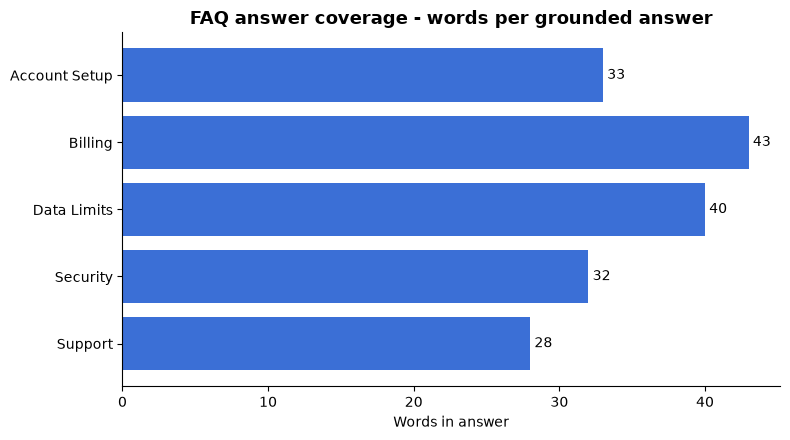

In [5]:
import matplotlib.pyplot as plt

labels = [it.question.replace("What do I need to know about ", "").rstrip("?") for it in faq.items]
lengths = [len(it.answer.split()) for it in faq.items]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(labels[::-1], lengths[::-1], color="#3b6fd6")
ax.set_title("FAQ answer coverage - words per grounded answer", fontsize=13, weight="bold")
ax.set_xlabel("Words in answer")
ax.bar_label(bars, padding=3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("faq_coverage.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| FAQ entry | Grounded in section |
|-----------|---------------------|
| Account setup | free trial, no card needed |
| Billing | monthly, prorated, cancel anytime |
| Data limits | 10 GB / 100 GB, throttled not blocked |
| Security | AES-256, TLS 1.3, SOC 2, 2FA |
| Support | 48h email vs 4h priority + live chat |

Five FAQ entries, every answer pulled verbatim from the doc - no hallucinated policy. This
is the RAG discipline that matters for support content: **ground every answer, or don't
ship it.**

## Upgrade to Claude (optional)

The heuristic turns headings into questions. Claude writes the questions customers
*actually* ask ("Do I need a credit card to try it?") and still answers only from the doc.
Set `ANTHROPIC_API_KEY` and the production `faqgen.py` routes to the LLM automatically -
same `FAQSet` shape, so the chart and Streamlit app are unchanged.

In [6]:
# import os, json, anthropic
#
# def llm_faq(text, api_key, max_items=8):
#     chunks = chunk_document(text)
#     context = "\n\n---\n\n".join(f"[chunk {i}] {c}" for i, c in enumerate(chunks))
#     client = anthropic.Anthropic(api_key=api_key)
#     resp = client.messages.create(
#         model="claude-sonnet-4-5", max_tokens=2000,
#         messages=[{"role": "user", "content":
#             f"Write up to {max_items} FAQ entries, answered ONLY from the doc. JSON only.\n" + context}],
#     )
#     data = json.loads(resp.content[0].text)
#     return FAQSet([FAQItem(**it) for it in data["items"]])
#
# faq = llm_faq(SAMPLE_DOC, os.environ["ANTHROPIC_API_KEY"])


In [7]:
# --- Try your own doc ---
# my_doc = """
# # Your Product
# ## Section heading
# Paste your documentation here...
# """
# my_faq = heuristic_faq(my_doc)
# print(my_faq.to_markdown())


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) -
Day 34 of the 60-day FDE portfolio.

**Run the full app:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
The Streamlit version shows the grounding chunk behind each answer and exports the whole
FAQ as Markdown.